In [1]:
#Librerias
from datetime import datetime
import random
from typing import Annotated
from typing_extensions import TypedDict

from langchain_ollama.chat_models import ChatOllama
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.tools import tool
from langchain_core.runnables import Runnable, RunnableConfig, RunnableLambda
from langchain_core.messages import ToolMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import AnyMessage, add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

In [2]:
OLLAMA_HOST: str = '192.168.107.42'
OLLAMA_PORT: str = '11434'
OLLAMA_MODEL: str = 'llama3.1:latest'
OLLAMA_TEMPERATURE: int = 0
OLLAMA_TIMEOUT: int = 3600
OLLAMA_NUM_THREADS: int = 8

OLLAMA_URL= f"http://{OLLAMA_HOST}:{OLLAMA_PORT}"

llm = ChatOllama(
  base_url=OLLAMA_URL,
  model=OLLAMA_MODEL,
  num_thread=OLLAMA_NUM_THREADS,
  temperature=OLLAMA_TEMPERATURE,
  verbose = True
)


In [3]:
# Define State
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

"""
The Assistant class is designed this way for several reasons:
It encapsulates the behavior of the AI assistant as a callable object.
It takes a runnable as an argument, which allows for flexibility in what kind of AI model or chain is used.
The __call__ method makes the class instances directly callable, which is useful for integration with LangGraph.
It handles the logic for re-prompting if the AI returns an empty response, ensuring more robust interactions.
The class processes the input state, which contains the conversation history, and produces a response or tool call. This design allows for easy integration into the graph structure and provides a clean interface for the AI's behavior.
"""
class Assistant:
    def __init__(self, runnable: Runnable):
        self.runnable = runnable

    def __call__(self, state, config: RunnableConfig):
        while True:
            configuration = config.get("configurable", {})
            user_id = configuration.get("user_id", None)
            state = {**state, "user_info": user_id}
            result = self.runnable.invoke(state)
            # Re-prompt if LLM returns an empty response
            if not result.tool_calls and (
                not result.content
                or isinstance(result.content, list)
                and not result.content[0].get("text")
            ):
                messages = state["messages"] + [("user", "Respond with a real output.")]
                state = {**state, "messages": messages}
            else:
                break
        return {"messages": result}

In [4]:
primary_assistant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful assistant. Use the provided tools to assist with tasks such as fetching stock prices, getting current weather, and calculating age."
            "\n\nCurrent user:\n\n{user_info}\n"
            "\nCurrent time: {time}.",
        ),
        ("placeholder", "{messages}"),
    ]
).partial(time=datetime.now())


In [5]:
# Define the beginner-friendly tools
@tool
def fetch_stock_price(symbol: str):
    """Fetch the current stock price for a given symbol."""
    # Simulate API call
    # Generate a realistic price (between $1 and $1000)
    base_price = random.uniform(1, 1000)
    fluctuation = random.uniform(-0.05, 0.05)  # -5% to +5%
    price = round(base_price * (1 + fluctuation), 2)
    return f"The current price of {symbol} is ${price:.2f}"

@tool
def get_current_weather(location: str):
    """Get the current weather for a given location."""
    weather_conditions = ["Clear", "Partly Cloudy", "Cloudy", "Light Rain", "Heavy Rain", "Thunderstorm", "Snow", "Fog"]
    temperature = random.randint(-10, 40)
    condition = random.choice(weather_conditions)
    humidity = random.randint(30, 90)
    wind_speed = random.randint(0, 30)
    
    return f"Current weather in {location}:\n" \
            f"- Condition: {condition}\n" \
            f"- Temperature: {temperature}°C\n" \
            f"- Humidity: {humidity}%\n" \
            f"- Wind Speed: {wind_speed} km/h"
@tool
def get_time(city: str):
    """Get the current time for a given location"""
    return f"Current time in {city}:12:00\n"
    
@tool
def calculate_age(year_of_birth: int):
    """Calculate the age of a person given their year of birth."""
    current_year = datetime.now().year
    age = current_year - year_of_birth
    return f"A person born in {year_of_birth} is {age} years old."


tools_to_use = [fetch_stock_price, get_current_weather, calculate_age,get_time]


In [6]:
# Prompts
primary_assistant_prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant. Use the provided tools to assist with tasks such as fetching stock prices, getting current weather, getting current time ,and calculating age."
              "\n\nCurrent user:\n\n{user_info}\n"
              "\nCurrent time: {time}."),
    ("placeholder", "{messages}"),
]).partial(time=datetime.now())

# Runnables
assistant_runnable = primary_assistant_prompt | llm.bind_tools(tools_to_use)

In [7]:
# Helper functions
def handle_tool_error(error):
    return f"An error occurred while using the tool: {str(error)}"

def create_tool_node_with_fallback(tools: list) -> dict:
    return ToolNode(tools).with_fallbacks(
        [RunnableLambda(handle_tool_error)], exception_key="error"
    )

"""
This graph structure allows for a dynamic conversation flow:
1. The assistant generates a response or decides to use a tool.
If a tool is needed, the flow moves to the tools node.
After tool use, control returns to the assistant.
This cycle can repeat as needed throughout the conversation.
The design is powerful because it:
Separates concerns: The assistant logic and tool execution are in different nodes.
Allows for easy addition of new tools or modification of the assistant's behavior.
Provides a clear, visual way to understand and modify the conversation flow.
Enables complex interactions, like chained tool use or multi-step reasoning, without complicating the main assistant logic.
"""

builder = StateGraph(State)
builder.add_node("assistant", Assistant(assistant_runnable))
builder.add_node("tools", create_tool_node_with_fallback(tools_to_use))
builder.add_edge(START, "assistant")
builder.add_conditional_edges("assistant", tools_condition)
builder.add_edge("tools", "assistant")

graph = builder.compile()


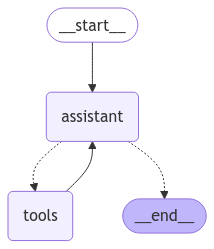

In [8]:
from IPython.display import Image, display

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [9]:
def _print_event(event: dict, _printed: set, max_length=1500):
    current_state = event.get("dialog_state")
    if current_state:
        print("Currently in: ", current_state[-1])
    message = event.get("messages")
    if message:
        if isinstance(message, list):
            message = message[-1]
        if message.id not in _printed:
            msg_repr = message.pretty_repr(html=True)
            if len(msg_repr) > max_length:
                msg_repr = msg_repr[:max_length] + " ... (truncated)"
            print(msg_repr)
            _printed.add(message.id)

In [10]:
# Compilar el grafo con memoria
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

# Configuración del hilo de conversación
import uuid
thread_id = str(uuid.uuid4())

config = {
    "configurable": {
        "user_id": "cplog",
        "thread_id": thread_id,
    }
}

# Función para ejecutar el flujo de conversación
_printed = set()
events = graph.stream(
    {"messages": ("user", 'hi, who was born in 1992')}, config, stream_mode="values"
)
for event in events:
    _print_event(event, _printed)

================================ Human Message =================================

hi, who was born in 1992
================================== Ai Message ==================================
Tool Calls:
  calculate_age (cf0b1c4f-bc6d-42f2-9aef-72272dd6c694)
 Call ID: cf0b1c4f-bc6d-42f2-9aef-72272dd6c694
  Args:
    year_of_birth: 1992
================================= Tool Message =================================
Name: calculate_age

A person born in 1992 is 33 years old.
================================== Ai Message ==================================

The current user cplog asked: When was the person born?

Answer: The person was born in 1992.


In [11]:
# "Quiero saber el clima en Madrid"
# Función para ejecutar el flujo de conversación
_printed = set()
events = graph.stream(
    {"messages": ("user", 'Quiero saber el clima en Madrid ')}, config, stream_mode="values"
)
for event in events:
    _print_event(event, _printed)

================================ Human Message =================================

Quiero saber el clima en Madrid 


KeyboardInterrupt: 

In [12]:
# "Quiero saber el clima en Madrid"
# Función para ejecutar el flujo de conversación
_printed = set()
events = graph.stream(
    {"messages": ("user", 'Quiero saber el clima en Madrid y la hora ')}, config, stream_mode="values"
)
for event in events:
    _print_event(event, _printed)

================================ Human Message =================================

Quiero saber el clima en Madrid y la hora 
================================== Ai Message ==================================
Tool Calls:
  get_current_weather (5534360e-c21f-45fb-819f-a27aff0b7048)
 Call ID: 5534360e-c21f-45fb-819f-a27aff0b7048
  Args:
    location: Madrid
  get_time (7ee5c9f6-516b-4e6f-b476-50177ecfe35e)
 Call ID: 7ee5c9f6-516b-4e6f-b476-50177ecfe35e
  Args:
    city: Madrid
================================= Tool Message =================================
Name: get_time

Current time in Madrid:12:00

================================== Ai Message ==================================

The current user cplog asked: Quiero saber el clima en Madrid y la hora.

Answer: The current weather in Madrid is Cloudy with a temperature of -2°C, humidity of 66%, and wind speed of 27 km/h. The current time in Madrid is 12:00.


## **Reasoning without Observation**

In [13]:
import operator
from typing import Annotated, List, Tuple
from typing_extensions import TypedDict
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate


class PlanExecute(TypedDict):
    input: str
    plan: List[str]
    past_steps: Annotated[List[Tuple], operator.add]
    response: str



class Plan(BaseModel):
    """Plan to follow in future"""

    steps: List[str] = Field(
        description="different steps to follow, should be in sorted order"
    )



planner_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """For the given objective, come up with a simple step by step plan. \
This plan should involve individual tasks, that if executed correctly will yield the correct answer. Do not add any superfluous steps. \
The result of the final step should be the final answer. Make sure that each step has all the information needed - do not skip steps. """,
        ),
        ("placeholder", "{messages}"),
    ]
)
planner = planner_prompt | llm.with_structured_output(Plan)

from typing import Union


class Response(BaseModel):
    """Response to user."""

    response: str


#class Act(BaseModel):
#    """Action to perform."""
#
#    action: Union[Response, Plan] = Field(
#        description="Action to perform. If you want to respond to user, use Response. "
#        "If you need to further use tools to get the answer, use Plan."
#    )

class Act(BaseModel):
    response: str
    action: str


replanner_prompt = ChatPromptTemplate.from_template(
    """For the given objective, come up with a simple step by step plan. \
This plan should involve individual tasks, that if executed correctly will yield the correct answer. Do not add any superfluous steps. \
The result of the final step should be the final answer. Make sure that each step has all the information needed - do not skip steps.

Your objective was this:
{input}

Your original plan was this:
{plan}

You have currently done the follow steps:
{past_steps}

Update your plan accordingly. If no more steps are needed and you can return to the user, then respond with that. Otherwise, fill out the plan. Only add steps to the plan that still NEED to be done. Do not return previously done steps as part of the plan."""
)

In [14]:
from typing import Literal
from langgraph.graph import END

async def execute_step(state: PlanExecute):
    plan = state["plan"]
    plan_str = "\n".join(f"{i+1}. {step}" for i, step in enumerate(plan))
    task = plan[0]
    task_formatted = f"""For the following plan:
{plan_str}\n\nYou are tasked with executing step {1}, {task}."""
    
    agent_response = await wiki_agent.ainvoke(
        {"messages": [("user", task_formatted)]}
    )
    
    return {
        "past_steps": state.get("past_steps", []) + [(task, agent_response["messages"][-1].content)],
        "response": agent_response["messages"][-1].content  # Agregado para evitar el error
    }



async def plan_step(state: PlanExecute):
    plan = await planner.ainvoke({"messages": [("user", state["input"])]})
    print(f"INFO - Pasos del plan {plan.steps}")
    return {"plan": plan.steps}


async def replan_step(state: PlanExecute):
    logging.getLogger('__name__').info(f"INFO - Into Plan {state}")
    
    output = await replanner.ainvoke({
        'input': state['input'], 
        'plan': state['plan'],
        'past_steps': state['past_steps']
    })
    
    if hasattr(output.action, 'response'):
        return {"response": output.action.response}
    elif hasattr(output.action, 'steps'):
        return {"plan": output.action.steps}
    else:
        return {"plan": [], "response": "No se pudo replanificar"}



def should_end(state: PlanExecute):
    if state.get("response"):
        return END
    elif "plan" in state and state["plan"]:
        return "agent"
    else:
        return "replan"

In [15]:
from langgraph.graph import StateGraph, START

# Crear el flujo de trabajo
workflow = StateGraph(PlanExecute)

# Agregar nodos
workflow.add_node("planner", plan_step)
#workflow.add_node("assistant", Assistant(assistant_runnable))
workflow.add_node("agent", execute_step)
workflow.add_node("replan", replan_step)

# Conectar nodos
workflow.add_edge(START, "planner")
workflow.add_edge("planner", "agent")
#workflow.add_edge("assistant", "agent")  # El assistant genera respuesta antes de ejecutar
workflow.add_edge("agent", "replan")

# Replan basado en la condición `should_end`
workflow.add_conditional_edges("replan", should_end, ["agent", END])

# Compilar workflow
app = workflow.compile()



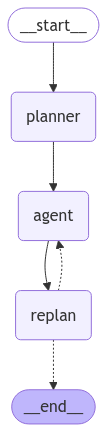

In [ ]:
from IPython.display import Image, display

display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [17]:
from langchain_core.messages import HumanMessage

config = {"configurable": {"user_id": "cplog"}}

state = {
    "messages": [HumanMessage(content="Quiero saber el clima en Madrid")],
    "plan": [],
    "execution_result": "",
    "tools": tools_to_use
}

events = app.stream(state, config)

for event in events:
    print(event)


TypeError: No synchronous function provided to "planner".
Either initialize with a synchronous function or invoke via the async API (ainvoke, astream, etc.)